# 02 — Structural parameters, steady-state targets, and asset grid

**Ports**: `Code/MATLAB/Main.m` lines 13–90 (target moments + structural parameters + derived steady-state quantities) and lines 92–160 (curved asset grid construction).

**Inputs**: `../output/markov.npz` (from notebook 01).

**Outputs (saved to `../output/params.npz`)**:
- All structural parameters (`alpha`, `gamma`, `theta`, `delta`, `omega`, …).
- Target moments from Hungarian data (`gdp`, `nw`, `nfa`, …).
- Derived steady-state quantities (`k_ss`, `y_ss`, `r_ss`, `w_ss`, `pi_ss`, `b_agg_ss`, `chi_dis`, `c_h`).
- Coarse asset grid `Agrid` and fine asset grid `Agrid_fine`.

## Imports + load Markov chain from notebook 01

In [1]:
from pathlib import Path

import numpy as np

OUTPUT_DIR = Path('..') / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

markov = np.load(OUTPUT_DIR / 'markov.npz')
ex = markov['ex']
piex = markov['piex']
exinv = markov['exinv']
ex_mean = float(markov['ex_mean'])
nx = int(markov['nx'])
ns = nx
print(f'Loaded {nx}-state Markov chain. ex_mean = {ex_mean:.10f}')

Loaded 7-state Markov chain. ex_mean = 1.0000000000


## Target moments (Hungary, pre-GFC)

Port of `Main.m` lines 13–25. All values are per-capita, thousands of EUR.

Sources cited inline in the MATLAB:
- `gr_inc` 7.9 — household pre-tax gross income (Eurostat I1).
- `deb_inc` 0.603 — median debt-to-income ratio (HFCS F4).
- `gdp` 12.65/4 — per-capita quarterly GDP.
- `nw` 26.2 — per-capita net wealth (HFCS A3).
- `nfa` -6.5 × 0.69 — per-capita NFA (Eurostat: total NFA = -65 bn EUR; population factor 0.69).

In [2]:
target = {
    'gr_inc': 7.9,
    'deb_inc': 0.603,
    'gdp': 12.65 / 4,
    'nw': 26.2,
    'nfa': -6.5 * 0.69,
    'nw_quintiles': np.array([0.9, 13.0, 26.2, 48.6, 84.1, 160.6]),
}
target['cap'] = -target['nfa'] + target['nw']
target['cap_gdp'] = target['cap'] / target['gdp']
target['nfa_gdp'] = target['nfa'] / target['gdp']

for k, v in target.items():
    print(f'  target.{k:<12s} = {v}')

# unresolved: paper §4.1.4 quotes a NFA-to-quarterly-GDP ratio of -2,
# but the MATLAB calibration computes -1.418 from the per-capita numbers.
# Using the MATLAB value verbatim for fidelity to the replication package.
print(f'\nNote: target.nfa_gdp = {target["nfa_gdp"]:.4f}  (paper text says -2.0)')

  target.gr_inc       = 7.9
  target.deb_inc      = 0.603
  target.gdp          = 3.1625
  target.nw           = 26.2
  target.nfa          = -4.484999999999999
  target.nw_quintiles = [  0.9  13.   26.2  48.6  84.1 160.6]
  target.cap          = 30.685
  target.cap_gdp      = 9.702766798418972
  target.nfa_gdp      = -1.418181818181818

Note: target.nfa_gdp = -1.4182  (paper text says -2.0)


## Structural parameters

Port of `Main.m` lines 27–43.

In [3]:
params = {
    'alpha': 0.33,         # capital share
    'gamma': 1.0,          # CRRA
    'delta': 0.08 / 4,     # quarterly depreciation
    'omega': 0.4,          # share of foreign goods in consumption
    'z_ss': 1.0,           # SS productivity, T-sector
    'T_ss': 1.0,           # SS terms of trade
    'nr': 0.96,            # Schmitt-Grohé--Uribe (Argentina) spread
    'varphi': 0.5,         # Frisch elasticity
    'epsilon_f': 10.0,     # EOS across home varieties
    'epsilon_w': 10.0,     # EOS across labour varieties
    'theta_nr': 100.0,     # Rotemberg adj cost; epsilon/theta = 0.1 (HANK)
    'l_bar': 1.0,          # labour upper bound
}
params['theta'] = 1.0 / params['gamma']  # restrict intra-EOS = 1/IES

params['nx'] = nx
params['ns'] = ns
params['rho'] = float(markov['rho'])
params['sigma_innov'] = float(markov['sigma_innov'])
params['ex'] = ex
params['piex'] = piex
params['exinv'] = exinv
params['ex_mean'] = ex_mean

for k in ['alpha', 'gamma', 'theta', 'delta', 'omega', 'varphi', 'epsilon_f', 'epsilon_w', 'theta_nr']:
    print(f'  params.{k:<10s} = {params[k]}')

  params.alpha      = 0.33
  params.gamma      = 1.0
  params.theta      = 1.0
  params.delta      = 0.02
  params.omega      = 0.4
  params.varphi     = 0.5
  params.epsilon_f  = 10.0
  params.epsilon_w  = 10.0
  params.theta_nr   = 100.0


## Steady-state derived quantities

Port of `Main.m` lines 64–89.

$$k_{ss} = \ell_{ss} (z_{ss}\cdot K/Y_{ss})^{1/(1-\alpha)}$$
$$y_{ss} = z_{ss} k_{ss}^\alpha \ell_{ss}^{1-\alpha}$$
$$r_{ss} = \frac{\varepsilon_f - 1}{\varepsilon_f}\,\alpha\, z_{ss} k_{ss}^{\alpha-1}\ell_{ss}^{1-\alpha} - \delta$$
$$w_{ss} = \frac{\varepsilon_f - 1}{\varepsilon_f}\,(1-\alpha)\,y_{ss}/\ell_{ss}$$

In [4]:
alpha = params['alpha']
delta = params['delta']
epsilon_f = params['epsilon_f']
epsilon_w = params['epsilon_w']
z_ss = params['z_ss']
T_ss = params['T_ss']
omega = params['omega']
varphi = params['varphi']
theta = params['theta']

params['k_y_ss'] = target['cap_gdp']                                    # 9.703
params['l_ss'] = params['l_bar'] * params['ex_mean']                    # = 1.0
params['k_ss'] = params['l_ss'] * (z_ss * params['k_y_ss']) ** (1.0 / (1.0 - alpha))
params['y_ss'] = z_ss * params['k_ss'] ** alpha * params['l_ss'] ** (1 - alpha)
params['r_ss'] = (
    (epsilon_f - 1.0) / epsilon_f
    * alpha * z_ss * params['k_ss'] ** (alpha - 1) * params['l_ss'] ** (1 - alpha)
    - delta
)
params['pi_ss'] = (1.0 / epsilon_f) * params['y_ss']
params['w_ss'] = (epsilon_f - 1.0) / epsilon_f * (1.0 - alpha) * params['y_ss'] / params['l_ss']

params['bmin'] = -1e-7 * params['k_y_ss'] * params['y_ss']
params['b_agg_ss'] = target['nfa_gdp'] * params['y_ss']

params['c_h'] = (
    1.0 / (1.0 + omega / (1 - omega))
    * (params['r_ss'] * (params['b_agg_ss'] + params['k_ss'])
       + params['l_ss'] * params['w_ss'] + params['pi_ss'])
)
params['chi_dis'] = (
    (1 - omega) * params['w_ss'] * (epsilon_w - 1) / epsilon_w
    / (params['c_h'] * params['l_ss'] ** varphi)
)

for k in ['k_y_ss', 'l_ss', 'k_ss', 'y_ss', 'r_ss', 'w_ss', 'pi_ss', 'bmin', 'b_agg_ss', 'c_h', 'chi_dis']:
    print(f'  params.{k:<10s} = {params[k]:.6f}')

  params.k_y_ss     = 9.702767
  params.l_ss       = 1.000000
  params.k_ss       = 29.715189
  params.y_ss       = 3.062548
  params.r_ss       = 0.010610
  params.w_ss       = 1.846716
  params.pi_ss      = 0.306255
  params.bmin       = -0.000003
  params.b_agg_ss   = -4.343250
  params.c_h        = 1.453298
  params.chi_dis    = 0.686182


### Cross-check against paper Table 1

Paper expects $K/Y \approx 9.70$ and quarterly $r$ around 1% (= 4% annual). With $K/Y = 9.703$, the implied $\alpha y/k = 0.33/9.703 = 0.034$; net of the markup wedge ($\varepsilon-1)/\varepsilon = 0.9$ and depreciation $\delta=0.02$, $r_{ss} \approx 0.012$ per quarter.

In [5]:
implied_KY = params['k_ss'] / params['y_ss']
annual_r = (1 + params['r_ss']) ** 4 - 1
print(f"Implied K/Y (quarterly) : {implied_KY:.4f}  (target {target['cap_gdp']:.4f})")
print(f"Implied r (quarterly)   : {params['r_ss']:.6f}")
print(f"Implied r (annualised)  : {annual_r * 100:.2f}%   (paper headline ~4%)")

assert np.isclose(implied_KY, target['cap_gdp'], atol=1e-10)

Implied K/Y (quarterly) : 9.7028  (target 9.7028)
Implied r (quarterly)   : 0.010610
Implied r (annualised)  : 4.31%   (paper headline ~4%)


## Asset grid construction

Port of `Main.m` lines 92–160.

The MATLAB uses two grids:
1. A **coarse grid** `Agrid` of `nA` points used in the EGM solver (off-grid policy decisions are allowed via interpolation).
2. A **fine grid** `Agrid_fine` of `nA_fine` points used to compute the stationary distribution.

Both grids share a curvature exponent `curv = 3` (more points at low assets where decisions are non-linear), span `[bmin, Amax]`, and have a node exactly at zero so the borrowing constraint is on-grid.

The point counts are determined by a doubling loop in MATLAB:

```matlab
Initial_value = 13;
for s = 1:1000
    Initial_value = 2*Initial_value - 1;
    if Initial_value > 100, break, end
end
params.nA = Initial_value;       % → 193
% ...continue doubling for the fine grid
for s = 1:1000
    Initial_value = 2*Initial_value - 1;
    if Initial_value > 500, break, end
end
nA_fine = Initial_value;         % → 769
```

We replicate the same doubling so the grid sizes match MATLAB exactly.

In [6]:
curv = 3
linsp_min = -0.2

v = 10 + abs(linsp_min) * 10 + 1
while True:
    v = 2 * v - 1
    if v > 100:
        break
nA = int(v)
while True:
    v = 2 * v - 1
    if v > 500:
        break
nA_fine = int(v)

print(f'nA      = {nA}')
print(f'nA_fine = {nA_fine}')

params['nA'] = nA
params['nA_fine'] = nA_fine
params['curv'] = curv
params['curv_fine'] = curv
params['linsp_min'] = linsp_min
params['Amax'] = -params['bmin'] * 999 / 1e-7  # MATLAB Main.m line 92

nA      = 193
nA_fine = 769


In [7]:
def build_curved_grid(linsp_min, n_points, bmin, Amax, curv):
    """Build a curvature-3 asset grid spanning [bmin, Amax] with a node at 0.

    Mirrors `Main.m` lines 113–148: `linsp_grid = linspace(linsp_min, 1, n)`,
    snap the closest point to exact zero, then map x -> bmin + (Amax-bmin)*x^curv.
    """
    linsp = np.linspace(linsp_min, 1.0, n_points)
    idx_zero = int(np.argmin(np.abs(linsp)))
    if abs(linsp[idx_zero]) < 1e-8:
        linsp[idx_zero] = 0.0
    if linsp[idx_zero] != 0.0:
        raise ValueError('Grid does not contain the borrowing constraint properly')
    grid = bmin + (Amax - bmin) * (linsp ** curv)
    return grid, idx_zero

Agrid, idx_bmin = build_curved_grid(linsp_min, nA, params['bmin'], params['Amax'], curv)
Agrid_fine, idx_bmin_fine = build_curved_grid(linsp_min, nA_fine, params['bmin'], params['Amax'], curv)

params['Agrid'] = Agrid
params['Agrid_fine'] = Agrid_fine
params['Amin'] = float(Agrid.min())
params['Index_b_min'] = idx_bmin
params['Index_b_min_fine'] = idx_bmin_fine

print(f'Agrid       : {nA} points spanning [{Agrid.min():.4f}, {Agrid.max():.4f}]')
print(f'Agrid_fine  : {nA_fine} points spanning [{Agrid_fine.min():.4f}, {Agrid_fine.max():.4f}]')
print(f'Agrid contains 0 at index {idx_bmin}: Agrid[{idx_bmin}] = {Agrid[idx_bmin]:.2e}')
print(f'Agrid_fine contains 0 at index {idx_bmin_fine}: Agrid_fine[{idx_bmin_fine}] = {Agrid_fine[idx_bmin_fine]:.2e}')

Agrid       : 193 points spanning [-237.4838, 29685.4739]
Agrid_fine  : 769 points spanning [-237.4838, 29685.4739]
Agrid contains 0 at index 32: Agrid[32] = -2.97e-06
Agrid_fine contains 0 at index 128: Agrid_fine[128] = -2.97e-06


### Visualise grid curvature

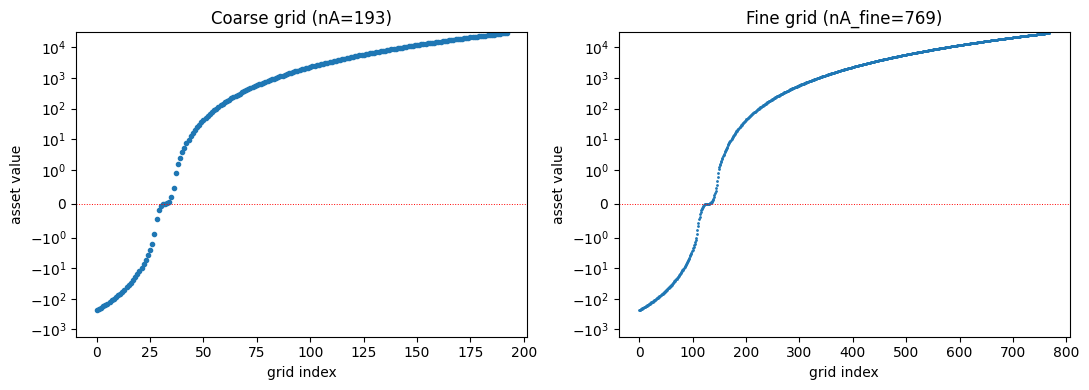

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(np.arange(nA), Agrid, marker='.', linestyle='none')
axes[0].axhline(0.0, color='red', lw=0.7, linestyle=':')
axes[0].set_xlabel('grid index')
axes[0].set_ylabel('asset value')
axes[0].set_title(f'Coarse grid (nA={nA})')
axes[0].set_yscale('symlog', linthresh=1.0)

axes[1].plot(np.arange(nA_fine), Agrid_fine, marker='.', linestyle='none', markersize=2)
axes[1].axhline(0.0, color='red', lw=0.7, linestyle=':')
axes[1].set_xlabel('grid index')
axes[1].set_ylabel('asset value')
axes[1].set_title(f'Fine grid (nA_fine={nA_fine})')
axes[1].set_yscale('symlog', linthresh=1.0)

plt.tight_layout()
plt.show()

## Save outputs

Numpy arrays go into `../output/params.npz`; non-array fields (markov chain pieces, structural scalars) too.

In [9]:
out_path = OUTPUT_DIR / 'params.npz'

scalar_keys = [
    'alpha', 'gamma', 'theta', 'delta', 'omega', 'z_ss', 'T_ss', 'nr', 'varphi',
    'epsilon_f', 'epsilon_w', 'theta_nr', 'l_bar', 'nx', 'ns', 'rho', 'sigma_innov',
    'k_y_ss', 'l_ss', 'k_ss', 'y_ss', 'r_ss', 'pi_ss', 'w_ss', 'bmin', 'b_agg_ss',
    'c_h', 'chi_dis', 'nA', 'nA_fine', 'curv', 'curv_fine', 'linsp_min', 'Amax',
    'Amin', 'Index_b_min', 'Index_b_min_fine', 'ex_mean',
]
array_keys = ['ex', 'piex', 'exinv', 'Agrid', 'Agrid_fine']
target_keys = list(target.keys())

save_dict = {f'params__{k}': np.asarray(params[k]) for k in scalar_keys + array_keys}
save_dict.update({f'target__{k}': np.asarray(target[k]) for k in target_keys})

np.savez(out_path, **save_dict)
print(f'Saved: {out_path.resolve()}')
print(f'  {len(save_dict)} fields total')

Saved: /Users/siyingli/github/de-Ferra2020-kz/Code/Python/output/params.npz
  52 fields total
